<a href="https://colab.research.google.com/github/abbasusman0009/traffic_model_predictions/blob/main/dataset_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install numpy pandas matplotlib seaborn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

print('✅ Libraries ready')

✅ Libraries ready


In [5]:
# from google.colab import drive
# drive.mount('/content/drive')

# ✏️ Change this to where pems04.npz is in your Drive
FILE_PATH = '/content/drive/MyDrive/pems04.npz'

# Load the file
raw  = np.load(FILE_PATH, allow_pickle=True)
data = raw['data']   # shape: (T, N, F)

T, N, F = data.shape
STEPS_PER_DAY = 288  # 5-min intervals × 12 per hour × 24 hours

print('✅ PeMS04 loaded successfully!')
print(f'   Shape     : {data.shape}  (timesteps x sensors x features)')
print(f'   Duration  : {T} timesteps = {T / STEPS_PER_DAY:.1f} days')
print(f'   Sensors   : {N}')
print(f'   Features  : {F}  →  [Flow, Occupancy, Speed]')

✅ PeMS04 loaded successfully!
   Shape     : (16992, 307, 3)  (timesteps x sensors x features)
   Duration  : 16992 timesteps = 59.0 days
   Sensors   : 307
   Features  : 3  →  [Flow, Occupancy, Speed]


In [6]:
feature_names = ['Flow', 'Occupancy', 'Speed']

print('=== PeMS04 Basic Statistics ===')
print(f'  Timesteps : {T}')
print(f'  Sensors   : {N}')
print(f'  Days      : {T / STEPS_PER_DAY:.1f}')
print()

for i, fname in enumerate(feature_names):
    feat = data[:, :, i]
    print(f'  [{fname}]')
    print(f'    Min  : {feat.min():.2f}')
    print(f'    Max  : {feat.max():.2f}')
    print(f'    Mean : {feat.mean():.2f}')
    print(f'    Std  : {feat.std():.2f}')
    print()

=== PeMS04 Basic Statistics ===
  Timesteps : 16992
  Sensors   : 307
  Days      : 59.0

  [Flow]
    Min  : 0.00
    Max  : 919.00
    Mean : 211.70
    Std  : 158.07

  [Occupancy]
    Min  : 0.00
    Max  : 0.77
    Mean : 0.05
    Std  : 0.05

  [Speed]
    Min  : 3.00
    Max  : 85.20
    Mean : 63.47
    Std  : 8.36



In [7]:
nan_total = np.isnan(data).sum()
nan_pct   = 100 * nan_total / data.size

zero_flow = (data[:, :, 0] == 0).sum()
zero_pct  = 100 * zero_flow / (T * N)

print('=== Missing Data Check ===')
print(f'  NaN values  : {nan_total}  ({nan_pct:.3f}%)')
print(f'  Zero flows  : {zero_flow}  ({zero_pct:.2f}%)')

# If there are NaNs, fill them using forward fill
if nan_total > 0:
    print('  Applying forward-fill to fix NaNs...')
    for f in range(F):
        df_tmp = pd.DataFrame(data[:, :, f])
        df_tmp.ffill(inplace=True)
        df_tmp.bfill(inplace=True)
        data[:, :, f] = df_tmp.values
    print(f'  NaNs remaining after fix: {np.isnan(data).sum()}')
else:
    print('  No NaNs found — data is clean!')

=== Missing Data Check ===
  NaN values  : 0  (0.000%)
  Zero flows  : 82935  (1.59%)
  No NaNs found — data is clean!


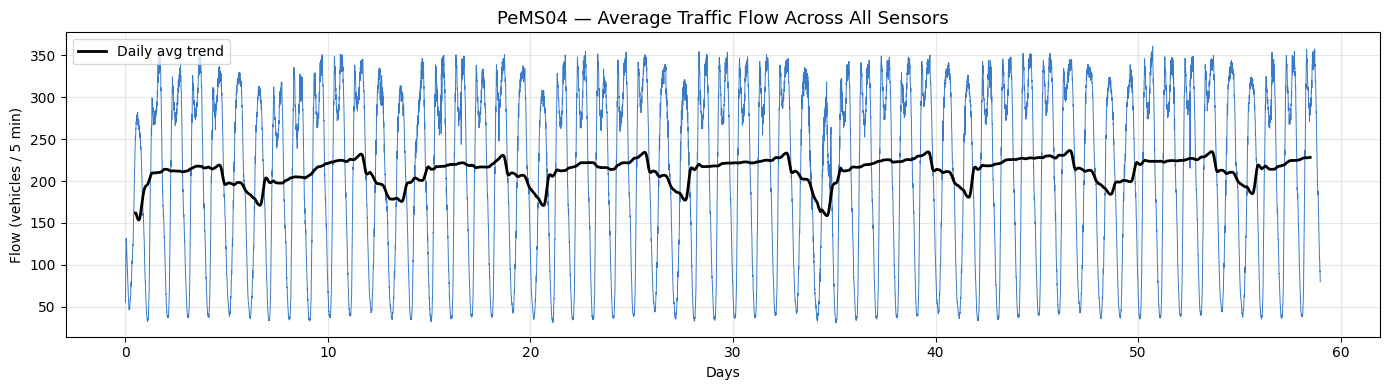

In [8]:
# Average flow across all sensors at each timestep
avg_flow = data[:, :, 0].mean(axis=1)   # shape: (T,)
x_days   = np.arange(T) / STEPS_PER_DAY

plt.figure(figsize=(14, 4))
plt.plot(x_days, avg_flow, color='#1565C0', linewidth=0.7, alpha=0.85)

# Smooth trend line (1-day rolling average)
smooth = pd.Series(avg_flow).rolling(STEPS_PER_DAY, center=True).mean()
plt.plot(x_days, smooth, color='black', linewidth=2, label='Daily avg trend')

plt.title('PeMS04 — Average Traffic Flow Across All Sensors', fontsize=13)
plt.xlabel('Days')
plt.ylabel('Flow (vehicles / 5 min)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

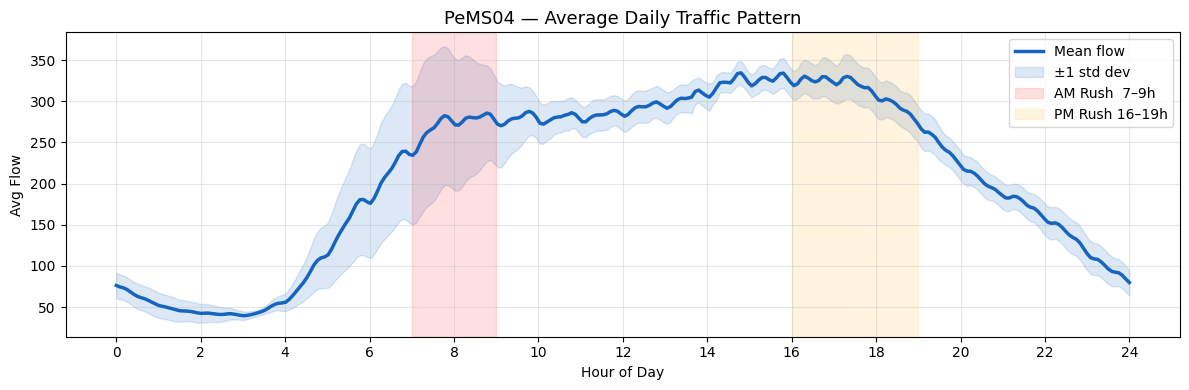

Peak traffic hour: 14.8h  |  Peak avg flow: 334.49


In [9]:
# Reshape flow into (n_days, 288) to compute average day
# This reveals the morning and evening rush hour peaks

flow     = data[:, :, 0].mean(axis=1)
n_days   = T // STEPS_PER_DAY
flow_2d  = flow[:n_days * STEPS_PER_DAY].reshape(n_days, STEPS_PER_DAY)

avg_day = flow_2d.mean(axis=0)
std_day = flow_2d.std(axis=0)
hours   = np.linspace(0, 24, STEPS_PER_DAY)

plt.figure(figsize=(12, 4))
plt.plot(hours, avg_day, color='#1565C0', linewidth=2.5, label='Mean flow')
plt.fill_between(hours, avg_day - std_day, avg_day + std_day,
                 alpha=0.15, color='#1565C0', label='±1 std dev')
plt.axvspan(7,  9,  alpha=0.12, color='red',    label='AM Rush  7–9h')
plt.axvspan(16, 19, alpha=0.12, color='orange', label='PM Rush 16–19h')

plt.title('PeMS04 — Average Daily Traffic Pattern', fontsize=13)
plt.xlabel('Hour of Day')
plt.ylabel('Avg Flow')
plt.xticks(range(0, 25, 2))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

peak_hour = hours[np.argmax(avg_day)]
print(f'Peak traffic hour: {peak_hour:.1f}h  |  Peak avg flow: {avg_day.max():.2f}')

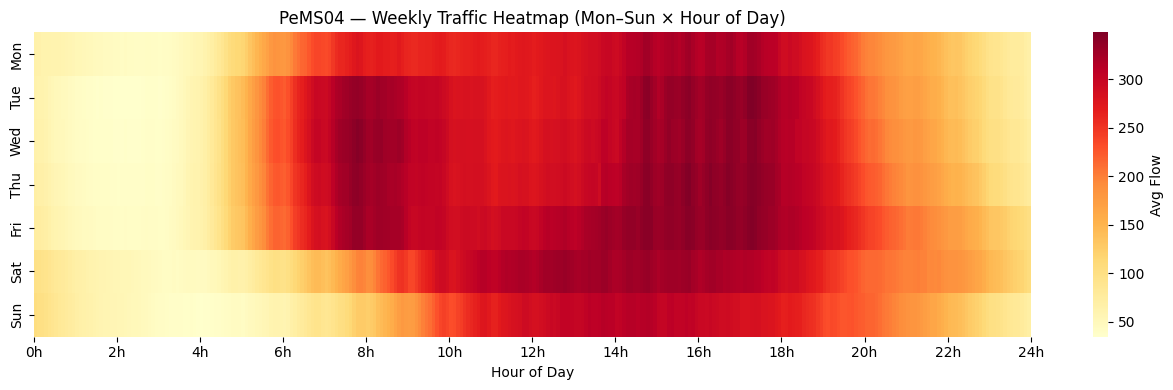

In [10]:
# Group days by weekday to see Mon–Sun traffic differences

n_weeks  = n_days // 7
flow_wk  = flow_2d[:n_weeks * 7].reshape(n_weeks, 7, STEPS_PER_DAY)
mean_week = flow_wk.mean(axis=0)   # shape: (7, 288)

day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

plt.figure(figsize=(13, 4))
sns.heatmap(mean_week,
            cmap='YlOrRd',
            yticklabels=day_labels,
            xticklabels=False,
            cbar_kws={'label': 'Avg Flow'})

# Add hour labels on x-axis
tick_positions = [i * 12 for i in range(0, 25, 2)]  # every 2 hours
tick_labels    = [f'{i*2}h' for i in range(0, 13)]
plt.xticks(ticks=tick_positions, labels=tick_labels, rotation=0)

plt.title('PeMS04 — Weekly Traffic Heatmap (Mon–Sun × Hour of Day)', fontsize=12)
plt.xlabel('Hour of Day')
plt.tight_layout()
plt.show()

=== Descriptive Statistics ===
            Flow  Occupancy      Speed
count  16992.000  16992.000  16992.000
mean     211.701      0.053     63.471
std      106.249      0.030      3.861
min       30.726      0.008     48.269
25%      105.138      0.023     61.233
50%      246.888      0.056     64.669
75%      305.954      0.074     66.745
max      360.928      0.128     68.620


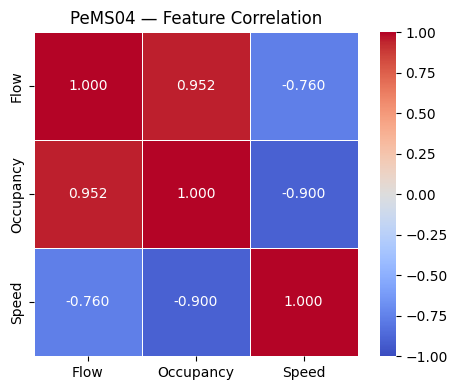

In [11]:
# Average each feature across all sensors, then check correlations
# Expected: Flow & Occupancy positive | Flow & Speed negative at high volume

df_features = pd.DataFrame({
    'Flow'      : data[:, :, 0].mean(axis=1),
    'Occupancy' : data[:, :, 1].mean(axis=1),
    'Speed'     : data[:, :, 2].mean(axis=1),
})

print('=== Descriptive Statistics ===')
print(df_features.describe().round(3))

plt.figure(figsize=(5, 4))
sns.heatmap(df_features.corr(),
            annot=True, fmt='.3f',
            cmap='coolwarm', vmin=-1, vmax=1,
            square=True, linewidths=0.5)
plt.title('PeMS04 — Feature Correlation', fontsize=12)
plt.tight_layout()
plt.show()

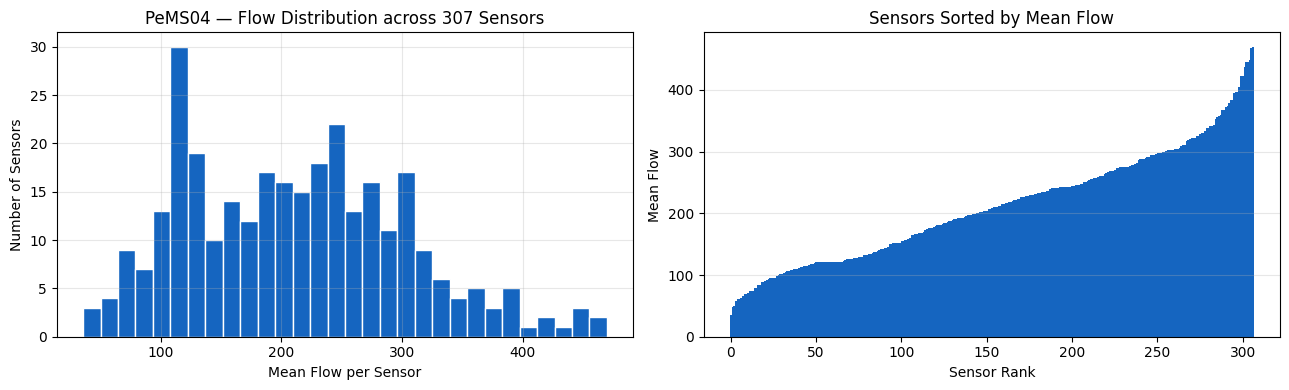

Lowest  flow sensor : 35.71
Highest flow sensor : 469.70
Median              : 208.28


In [12]:
# Some sensors sit on busy roads, others on quiet ones
# This shows how much traffic varies across the network

mean_per_sensor = data[:, :, 0].mean(axis=0)   # avg flow per sensor

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
axes[0].hist(mean_per_sensor, bins=30, color='#1565C0', edgecolor='white')
axes[0].set_title(f'PeMS04 — Flow Distribution across {N} Sensors')
axes[0].set_xlabel('Mean Flow per Sensor')
axes[0].set_ylabel('Number of Sensors')
axes[0].grid(True, alpha=0.3)

# Sorted bar — each bar = one sensor
axes[1].bar(range(N), np.sort(mean_per_sensor), color='#1565C0', width=1.0)
axes[1].set_title('Sensors Sorted by Mean Flow')
axes[1].set_xlabel('Sensor Rank')
axes[1].set_ylabel('Mean Flow')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f'Lowest  flow sensor : {mean_per_sensor.min():.2f}')
print(f'Highest flow sensor : {mean_per_sensor.max():.2f}')
print(f'Median              : {np.median(mean_per_sensor):.2f}')

In [13]:
# Build summary table
summary = pd.DataFrame([{
    'Dataset'        : 'PeMS04',
    'Type'           : 'Loop Detector',
    'Location'       : 'California, USA',
    'Sensors'        : N,
    'Timesteps'      : T,
    'Days'           : round(T / STEPS_PER_DAY, 1),
    'Avg_Flow'       : round(data[:,:,0].mean(), 2),
    'Max_Flow'       : round(data[:,:,0].max(), 2),
    'Avg_Occupancy'  : round(data[:,:,1].mean(), 4),
    'Avg_Speed'      : round(data[:,:,2].mean(), 2),
    'NaN_Count'      : int(np.isnan(data).sum()),
    'Peak_Hour'      : round(peak_hour, 1),
}])

print('=== PeMS04 SUMMARY ===')
display(summary.T.rename(columns={0: 'Value'}))

# Save CSV for Looker Studio
out_path = '/content/drive/MyDrive/dataset_summary.csv'
summary.to_csv(out_path, index=False)
print(f'\n✅ Summary saved → {out_path}')
print('✅ Analysis complete!')
# print('👉 Next step: drive_me_crazy_tradi.ipynb  (Traditional Model)')

=== PeMS04 SUMMARY ===


,Value
Dataset,PeMS04
Type,Loop Detector
Location,"California, USA"
Sensors,307
Timesteps,16992
Days,59.0
Avg_Flow,211.7
Max_Flow,919.0
Avg_Occupancy,0.0528
Avg_Speed,63.47



✅ Summary saved → /content/drive/MyDrive/dataset_summary.csv
✅ Analysis complete!
